# Data Analysis: Ability, Benevolence, Integrity
This script contains the data analysis for Ability, Benevolence, Integrity.

### Content:
* Omega Coefficient for each scale
* Mean and SD per group for each sub-dimension
* Stacked percentage bar chart

In [ ]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 3.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import pingouin as pg
import scipy.stats as stats

# Load data (csv format)

file_path = "/content/results-filtered-94.csv" # Replace with your filename
df = pd.read_csv(file_path, sep=";")

print(f"Data shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Removes the string descriptions in the data
df = df.replace("7 (strongly agree)", "7")
df = df.replace("1 (strongly disagree)", "1")

Data shape: 94 rows, 80 columns



In [26]:
# Prepare independent variables for two-way ART ANOVA

language_mapping = {
    1: "Gender-Specific",
    2: "Gender-Neutral",
    3: "Gender-Specific",
    4: "Gender-Neutral"
}

style_mapping = {
    1: "Empathetic",
    2: "Empathetic",
    3: "Neutral",
    4: "Neutral"
}

df['Language'] = df['group'].map(language_mapping)
df['Style'] = df['group'].map(style_mapping)

print("Preview of decoded groups:")
print(df[['group', 'Language', 'Style']].drop_duplicates().to_string(index=False))


Preview of decoded groups:
 group        Language      Style
     3 Gender-Specific    Neutral
     2  Gender-Neutral Empathetic
     1 Gender-Specific Empathetic
     4  Gender-Neutral    Neutral


Ability

In [ ]:
# Transform strings to numeric values
df["PO2T[SQ002]"] = pd.to_numeric(df["PO2T[SQ002]"], errors="coerce")
df["PO2T[SQ003]"] = pd.to_numeric(df["PO2T[SQ003]"], errors="coerce")
df["PO2T[SQ004]"] = pd.to_numeric(df["PO2T[SQ004]"], errors="coerce")

# Define dimension items
dimension_items_ability = ["PO2T[SQ002]", "PO2T[SQ003]", "PO2T[SQ004]"]

# Create a subset dataframe containing just these 3 items
df_dim_ability = df[dimension_items_ability].dropna()


In [ ]:
!Rscript -e "install.packages('psych', repos='https://cloud.r-project.org')"


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘mnormt’, ‘GPArotation’

trying URL 'https://cloud.r-project.org/src/contrib/mnormt_2.1.2.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/GPArotation_2026.6-1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/psych_2.6.5.tar.gz'
* installing *source* package ‘mnormt’ ...
** this is package ‘mnormt’ version ‘2.1.2’
** package ‘mnormt’ successfully unpacked and MD5 sums checked
** using staged installation
** libs
using C compiler: ‘cc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0’
using Fortran compiler: ‘GNU Fortran (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0’
f77  -fpic  -g -O2 -ffile-prefix-map=/build/r-base-gN72Ro/r-base-4.6.0=. -fstack-protector-strong  -c biv-nt.f -o biv-nt.o
cc -I"/usr/share/R/include" -DNDEBUG       -fpic  -g -O2 -ffile-prefix-map=/build/r-base-gN72Ro/r-base-4.6.0=. -fstack-protector-strong -Wformat -Werror=format-security -Wdate-time -D

In [ ]:
%load_ext rpy2.ipython

In [ ]:
%%R -i df_dim_ability

library(psych)

# Calculate McDonald's Omega
# nfactors=1 because 3 items belong to a single category
omega_result <- omega(df_dim_ability, nfactors=1, plot=FALSE)

print(omega_result)


Omega 
Call: omegah(m = m, nfactors = nfactors, fm = fm, key = key, flip = flip, 
    digits = digits, title = title, sl = sl, labels = labels, 
    plot = plot, n.obs = n.obs, rotate = rotate, Phi = Phi, option = option, 
    covar = covar)
Alpha:                 0.78 
G.6:                   0.73 
Omega Hierarchical:    0.8 
Omega H asymptotic:    1 
Omega Total            0.8 

Schmid Leiman Factor loadings greater than  0.2 
               g  F1*   h2   h2   u2 p2 com
PO2T[SQ002] 0.93      0.87 0.87 0.13  1   1
PO2T[SQ003] 0.77      0.60 0.60 0.40  1   1
PO2T[SQ004] 0.53      0.28 0.28 0.72  1   1

With Sums of squares  of:
  g F1*  h2 
1.7 0.0 1.2 

general/max  1.47   max/min =   2.132344e+16
mean percent general =  1    with sd =  0 and cv of  0 
Explained Common Variance of the general factor =  1 

The degrees of freedom are 0  and the fit is  0 
The number of observations was  94  with Chi Square =  0  with prob <  NA
The root mean square of the residuals is  0 
The df correct

Omega_h for 1 factor is not meaningful, just omega_t
In addition: Warning message:
In schmid(m, nfactors, fm, digits, rotate = rotate, n.obs = n.obs,  :
  Omega_h and Omega_asymptotic are not meaningful with one factor


In [ ]:
# Aggregate data (mean & SD)

# Calculate the mean across the rows for 3 items
# This creates a new column in the original dataframe
df["Ability_Mean_Score"] = df_dim_ability.mean(axis=1)

# Calculate the mean of the participant means, grouped by the 'group' column
group_means = df.groupby('group')['Ability_Mean_Score'].mean()
group_sd = df.groupby('group')['Ability_Mean_Score'].std()

print("--- Ability mean scores per group ---")
print(group_means)

# high sd = values are spread out further from mean
# low sd = data points cluster closer to mean
print("--- Ability SD per group ---")
print(group_sd)

--- Ability mean scores per group ---
group
1    4.115942
2    4.090909
3    4.360000
4    4.444444
Name: Ability_Mean_Score, dtype: float64
--- Ability SD per group ---
group
1    1.465456
2    1.505481
3    1.367344
4    1.313868
Name: Ability_Mean_Score, dtype: float64


Benevolence

In [ ]:
df["PO2T[SQ008]"] = pd.to_numeric(df["PO2T[SQ008]"], errors="coerce")
df["PO2T[SQ010]"] = pd.to_numeric(df["PO2T[SQ010]"], errors="coerce")
df["PO2T[SQ012]"] = pd.to_numeric(df["PO2T[SQ012]"], errors="coerce")

dimension_items_benevolence = ["PO2T[SQ008]", "PO2T[SQ010]", "PO2T[SQ012]"]

# Create a subset dataframe containing just these 3 items
df_dim_benevolence = df[dimension_items_benevolence].dropna()

In [ ]:
%%R -i df_dim_benevolence

library(psych)

# Calculate McDonald's Omega
# nfactors=1 because your 3 items belong to a single category/construct
omega_result <- omega(df_dim_benevolence, nfactors=1, plot=FALSE)

print(omega_result)

Omega 
Call: omegah(m = m, nfactors = nfactors, fm = fm, key = key, flip = flip, 
    digits = digits, title = title, sl = sl, labels = labels, 
    plot = plot, n.obs = n.obs, rotate = rotate, Phi = Phi, option = option, 
    covar = covar)
Alpha:                 0.62 
G.6:                   0.54 
Omega Hierarchical:    0.64 
Omega H asymptotic:    1 
Omega Total            0.64 

Schmid Leiman Factor loadings greater than  0.2 
               g  F1*   h2   h2   u2 p2 com
PO2T[SQ008] 0.71      0.50 0.50 0.50  1   1
PO2T[SQ010] 0.42           0.17 0.83  1   1
PO2T[SQ012] 0.69      0.47 0.47 0.53  1   1

With Sums of squares  of:
  g F1*  h2 
1.1 0.0 0.5 

general/max  2.28   max/min =   6.011968e+15
mean percent general =  1    with sd =  0 and cv of  0 
Explained Common Variance of the general factor =  1 

The degrees of freedom are 0  and the fit is  0 
The number of observations was  94  with Chi Square =  0  with prob <  NA
The root mean square of the residuals is  0 
The df corre

Omega_h for 1 factor is not meaningful, just omega_t
In addition: Warning message:
In schmid(m, nfactors, fm, digits, rotate = rotate, n.obs = n.obs,  :
  Omega_h and Omega_asymptotic are not meaningful with one factor


In [ ]:
# Aggregate data (mean & SD)

# Calculate the mean across the rows for 3 items
# This creates a new column in the original dataframe
df["Benevolence_Mean_Score"] = df_dim_benevolence.mean(axis=1)

# Calculate the mean of the participant means, grouped by the 'group' column
group_means = df.groupby('group')['Benevolence_Mean_Score'].mean()
group_sd = df.groupby('group')['Benevolence_Mean_Score'].std()

print("--- Benevolence mean scores per group ---")
print(group_means)

# high sd = values are spread out further from mean
# low sd = data points cluster closer to mean
print("--- Benevolence SD per group ---")
print(group_sd)


--- Benevolence mean scores per group ---
group
1    4.275362
2    4.166667
3    4.040000
4    3.791667
Name: Benevolence_Mean_Score, dtype: float64
--- Benevolence SD per group ---
group
1    1.285711
2    1.258831
3    1.214572
4    1.307032
Name: Benevolence_Mean_Score, dtype: float64


Integrity

In [ ]:
df["PO2T[SQ013]"] = pd.to_numeric(df["PO2T[SQ013]"], errors="coerce")
df["PO2T[SQ014]"] = pd.to_numeric(df["PO2T[SQ014]"], errors="coerce")
df["PO2T[SQ016]"] = pd.to_numeric(df["PO2T[SQ016]"], errors="coerce")

# Define dimension items

dimension_items_integrity = ["PO2T[SQ013]", "PO2T[SQ014]", "PO2T[SQ016]"]

# Create a subset dataframe containing just these 3 items
df_dim_integrity = df[dimension_items_integrity].dropna().copy()  # dropna() ensures rows with missing values don't break the tests


# Reverse scoring for one item
df_dim_integrity["PO2T[SQ014]"] = 8 - df_dim_integrity["PO2T[SQ014]"]


In [ ]:
%%R -i df_dim_integrity

library(psych)

# Calculate McDonald's Omega
# nfactors=1 because your 3 items belong to a single category/construct
omega_result <- omega(df_dim_integrity, nfactors=1, plot=FALSE)

print(omega_result)

Omega 
Call: omegah(m = m, nfactors = nfactors, fm = fm, key = key, flip = flip, 
    digits = digits, title = title, sl = sl, labels = labels, 
    plot = plot, n.obs = n.obs, rotate = rotate, Phi = Phi, option = option, 
    covar = covar)
Alpha:                 0.51 
G.6:                   0.46 
Omega Hierarchical:    0.62 
Omega H asymptotic:    1.02 
Omega Total            0.61 

Schmid Leiman Factor loadings greater than  0.2 
               g  F1*   h2   h2    u2 p2 com
PO2T[SQ013] 1.01      1.01 1.01 -0.01  1   1
PO2T[SQ014] 0.37           0.13  0.87  1   1
PO2T[SQ016] 0.31           0.10  0.90  1   1

With Sums of squares  of:
  g F1*  h2 
1.2 0.0 1.1 

general/max  1.18   max/min =   Inf
mean percent general =  1    with sd =  0 and cv of  0 
Explained Common Variance of the general factor =  1 

The degrees of freedom are 0  and the fit is  0.01 
The number of observations was  94  with Chi Square =  1.16  with prob <  NA
The root mean square of the residuals is  0.03 
The d

Omega_h for 1 factor is not meaningful, just omega_t
In addition: Warning messages:
1: In fac(r = r, nfactors = nfactors, n.obs = n.obs, rotate = rotate,  :
  An ultra-Heywood case was detected.  Examine the results carefully
2: In schmid(m, nfactors, fm, digits, rotate = rotate, n.obs = n.obs,  :
  Omega_h and Omega_asymptotic are not meaningful with one factor
3: In cov2cor(t(w) %*% r %*% w) :
  diag(V) had non-positive or NA entries; the non-finite result may be dubious


In [ ]:
# Aggregate data (mean & SD)

# Calculate the mean across the rows for 3 items
# This creates a new column in the original dataframe
df["Integrity_Mean_Score"] = df_dim_integrity.mean(axis=1)

# Calculate the mean of the participant means, grouped by the 'group' column
group_means = df.groupby('group')['Integrity_Mean_Score'].mean()
group_sd = df.groupby('group')['Integrity_Mean_Score'].std()

print("--- Integrity mean scores per group ---")
print(group_means)

# high sd = values are spread out further from mean
# low sd = data points cluster closer to mean
print("--- Integrity SD per group ---")
print(group_sd)


--- Integrity mean scores per group ---
group
1    5.275362
2    4.606061
3    4.786667
4    5.069444
Name: Integrity_Mean_Score, dtype: float64
--- Integrity SD per group ---
group
1    0.967409
2    1.096586
3    1.154219
4    1.090048
Name: Integrity_Mean_Score, dtype: float64


Stacked percentage bar chart

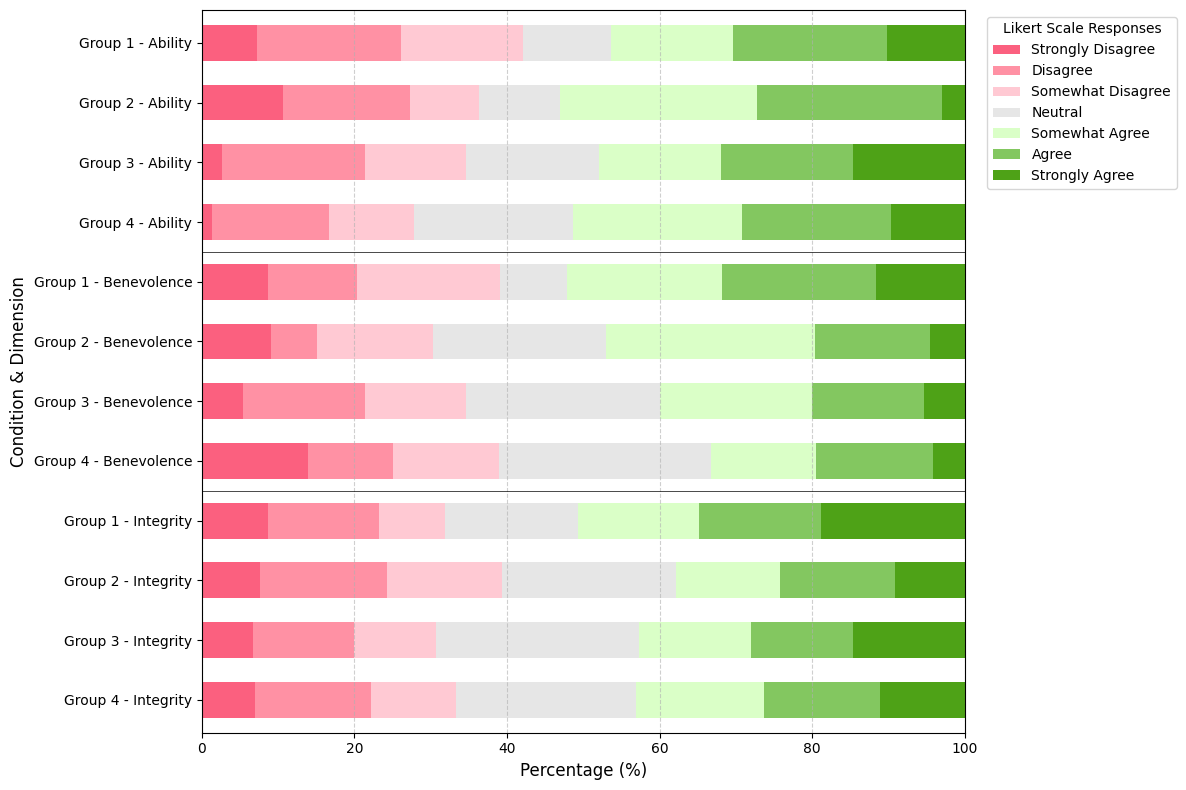

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ability_items = ["PO2T[SQ002]", "PO2T[SQ003]", "PO2T[SQ004]"]
benevolence_items = ["PO2T[SQ008]", "PO2T[SQ010]", "PO2T[SQ012]"]
integrity_items = ["PO2T[SQ013]", "PO2T[SQ014]", "PO2T[SQ016]"]

dimensions = {
    "Ability": ability_items,
    "Benevolence": benevolence_items,
    "Integrity": integrity_items,
}

likert_labels = [
    "Strongly Disagree",
    "Disagree",
    "Somewhat Disagree",
    "Neutral",
    "Somewhat Agree",
    "Agree",
    "Strongly Agree",
]

rows = []

# Order by dimension first, then group
for dim_name, item_list in dimensions.items():
    for group_num in sorted(df["group"].unique()):
        group_data = df[df["group"] == group_num]

        # Flatten items for this dimension into a single row
        flat_responses = group_data[item_list].values.flatten()

        # Count frequencies of scores 1 through 7
        counts = pd.Series(flat_responses).value_counts()

        # Fill scores with 0 counts
        counts = counts.reindex(range(1, 8), fill_value=0)

        # Convert counts into percentages that sum up to 100%
        percentages = (counts / counts.sum()) * 100

        # Save row data labeled by group and dimension
        row_entry = {"Label": f"Group {group_num} - {dim_name}"}
        for i, score_name in enumerate(likert_labels):
            row_entry[score_name] = percentages.iloc[i]

        rows.append(row_entry)

# Convert processed list into a plotting DataFrame
df_plot = pd.DataFrame(rows).set_index("Label")

likert_colors = [
    "#fb607f",  # Strongly Disagree (Deep Red)
    "#ff91a4",  # Disagree (Light Red)
    "#ffc9d3",  # Somewhat Disagree (Pink)
    "#e6e6e6",  # Neutral (Light Gray)
    "#daffc7",  # Somewhat Agree (Light Green)
    "#83c760",  # Agree (Medium Green)
    "#4ea217",  # Strongly Agree (Deep Green)
]

fig, ax = plt.subplots(figsize=(12, 8))

# Plot horizontal stacked bar chart
df_plot.plot(kind="barh", stacked=True, color=likert_colors, width=0.6, ax=ax)

# Reverse the vertical axis layout so group 1 appears at the top
ax.invert_yaxis()

# Add black lines between the dimensions
num_groups = len(df["group"].unique())
for i in range(1, len(dimensions)):
    ax.axhline(
        y=i * num_groups - 0.5, color="black", linestyle="-", linewidth=0.5
    )

ax.set_xlabel("Percentage (%)", fontsize=12)
ax.set_ylabel("Condition & Dimension", fontsize=12)
ax.set_xlim(0, 100)
ax.xaxis.grid(True, linestyle="--", alpha=0.6)

# Position the legend outside the chart on the right side
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Likert Scale Responses",
    frameon=True,
)

plt.tight_layout()
plt.show()